In [2]:
# import the libraries we will use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ignore warnings to keep the output clean
import warnings
warnings.filterwarnings('ignore')

# force pandas to show all the columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [3]:
# read the training file 
df = pd.read_csv('./data/data.csv')

# read the test file
test = pd.read_csv('./data/test.csv')

# read the submission template
sample = pd.read_csv('./data/sample_submission.csv')

In [4]:
print('train shape :', df.shape)
print('test shape  :', test.shape)
print('sample shape:', sample.shape)

train shape : (10578, 16)
test shape  : (3527, 15)
sample shape: (3527, 2)


In [5]:
df.head(3)

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
0,6046,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Inclusive,BTRAND NEW LUXURY VILLA FOR RENT AMWAJ,"Amwaj Avenue, Amwaj Islands",Muharraq Governorate,3+ Maid,4,"2,368 sqft / 220 sqm",9 Apr 2025,Savio Fernandes,Almoayyed property solutions,6.0,1000.0
1,2240,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,First Resident | Quiet Area | Luxurious,Diyar Al Muharraq,Muharraq Governorate,5,6,"3,229 sqft / 300 sqm",16 Sep 2025,Al Lagoon Real Estate,Al Lagoon Real Estate,5.0,700.0
2,6248,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Studio Apartment for rent located in Juffair,Al Juffair,Capital Governorate,studio,1,484 sqft / 45 sqm,17 Aug 2025,Najeeb Hejres,Green Line Real Estate,12.0,260.0


In [6]:
print('train columns:', df.columns.to_list())
print('test columns :', test.columns.to_list())

train columns: ['Property_id', 'Offer', 'URL', 'Property_type', 'Include_w_e', 'Title', 'Area', 'Governorate', 'Beds', 'Baths', 'Size', 'Availability_date', 'Agent_name', 'Agency', 'Amenities', 'rent']
test columns : ['Property_id', 'Offer', 'URL', 'Property_type', 'Include_w_e', 'Title', 'Area', 'Governorate', 'Beds', 'Baths', 'Size', 'Availability_date', 'Agent_name', 'Agency', 'Amenities']


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10578 entries, 0 to 10577
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Property_id        10578 non-null  int64  
 1   Offer              10578 non-null  str    
 2   URL                10578 non-null  str    
 3   Property_type      10578 non-null  str    
 4   Include_w_e        10578 non-null  str    
 5   Title              10575 non-null  str    
 6   Area               10575 non-null  str    
 7   Governorate        10575 non-null  str    
 8   Beds               10578 non-null  str    
 9   Baths              10578 non-null  str    
 10  Size               10578 non-null  str    
 11  Availability_date  10059 non-null  str    
 12  Agent_name         10575 non-null  str    
 13  Agency             10575 non-null  str    
 14  Amenities          10272 non-null  float64
 15  rent               10575 non-null  float64
dtypes: float64(2), int64(1), str(13)


In [8]:
# count the missing values in each column, for train and for test files
print(f'Train: {df.isnull().sum()}')
print()
print()
print(f'Test: {test.isnull().sum()}')

Train: Property_id            0
Offer                  0
URL                    0
Property_type          0
Include_w_e            0
Title                  3
Area                   3
Governorate            3
Beds                   0
Baths                  0
Size                   0
Availability_date    519
Agent_name             3
Agency                 3
Amenities            306
rent                   3
dtype: int64


Test: Property_id            0
Offer                  0
URL                    0
Property_type          0
Include_w_e            0
Title                  0
Area                   0
Governorate            0
Beds                   0
Baths                  0
Size                   0
Availability_date    168
Agent_name             0
Agency                 0
Amenities             86
dtype: int64


In [9]:
# check for fully duplicated rows
print('duplicated rows:', df.duplicated().sum())

# Property_id is supposed to be unique, let's check
print('duplicated Property_id:', df['Property_id'].duplicated().sum())

# check duplicates while ignoring the id (the same listing saved more than once under two ids)
print('duplicated listings (ignoring Property_id):', df.drop(columns='Property_id').duplicated().sum())

duplicated rows: 0
duplicated Property_id: 0
duplicated listings (ignoring Property_id): 241


In [10]:
# summary statistics
df.describe()

,Property_id,Amenities,rent
count,10578.000000,10272.000000,10575.000000
mean,7059.734260,10.319996,718.750071
std,4080.910374,5.093414,5318.027519
min,2.000000,1.000000,50.000000
25%,3521.250000,6.000000,330.000000
50%,7023.500000,11.000000,450.000000
75%,10605.750000,14.000000,700.000000
max,14103.000000,25.000000,400000.000000


In [11]:
# summary for the TEXT columns
df.describe(exclude=np.number)

,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency
count,10578,10578,10578,10578,10575,10575,10575,10578,10578,10578,10059,10575,10575
unique,1,10337,11,2,9824,127,5,19,9,395,608,461,205
top,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,"Apartment for rent , in a great location:",Al Juffair,Capital Governorate,2,2,"1,292 sqft / 120 sqm",9 Sep 2025,Farhan Tariq,Instant Homz
freq,10578,5,8378,6477,18,1914,5308,3874,4260,923,190,241,469


In [12]:
# look at the values inside the main categorical columns one by one

print(df['Offer'].value_counts(dropna=False))
print()
print()
print(df['Property_type'].value_counts(dropna=False))
print()
print()
print(df['Include_w_e'].value_counts(dropna=False))
print()
print()
print(df['Governorate'].value_counts(dropna=False))

Offer
Rent    10578
Name: count, dtype: int64


Property_type
Apartment                       8378
Villa                           1855
Compound                         133
Duplex                            95
Penthouse                         69
Townhouse                         21
Whole Building                    18
Hotel Apartment                    6
Bulk Rent Unit                     1
Short Term & Hotel Apartment       1
Bungalow                           1
Name: count, dtype: int64


Include_w_e
Inclusive    6477
Exclusive    4101
Name: count, dtype: int64


Governorate
Capital Governorate     5308
Muharraq Governorate    2844
Northern Governorate    1857
Central Governorate      316
Southern Governorate     250
NaN                        3
Name: count, dtype: int64


In [13]:
# Beds, Baths and Size were read as str and not int - let's see why
print(df['Beds'].value_counts())
print()
print()
print(df['Baths'].value_counts())
print()
print()
print(df['Size'].value_counts())
print()
print()

Beds
2               3874
1               2201
3               1332
4+ Maid          832
3+ Maid          748
studio           595
2+ Maid          283
5+ Maid          253
4                236
5                 63
1+ Maid           49
6+ Maid           41
6                 20
7+                18
studio+ Maid       9
7++ Maid           7
7                  7
7+ Maid            7
0                  3
Name: count, dtype: int64


Baths
2       4260
3       2427
1       1583
4       1219
5        739
6        222
7         83
7+        44
none       1
Name: count, dtype: int64


Size
1,292 sqft / 120 sqm       923
1,399 sqft / 130 sqm       570
1,076 sqft / 100 sqm       436
1,184 sqft / 110 sqm       403
1,507 sqft / 140 sqm       364
                          ... 
4,510 sqft / 419 sqm         1
4,176 sqft / 388 sqm         1
2,626 sqft / 244 sqm         1
26,910 sqft / 2,500 sqm      1
6,383 sqft / 593 sqm         1
Name: count, Length: 395, dtype: int64




In [14]:
# check how many different values exist in the text columns
df[['Property_type', 'Governorate', 'Area', 'Agency', 'Agent_name']].nunique()

Property_type     11
Governorate        5
Area             127
Agency           205
Agent_name       461
dtype: int64

In [15]:
# target column
df['rent'].describe()

count     10575.000000
mean        718.750071
std        5318.027519
min          50.000000
25%         330.000000
50%         450.000000
75%         700.000000
max      400000.000000
Name: rent, dtype: float64

In [16]:
print('median rent :', df['rent'].median())
print('mean rent   :', df['rent'].mean())
print('skewness    :', df['rent'].skew())

median rent : 450.0
mean rent   : 718.7500709219859
skewness    : 53.889106111650975


In [17]:
# mean is much bigger than the median, it means a huge values are pulling it 

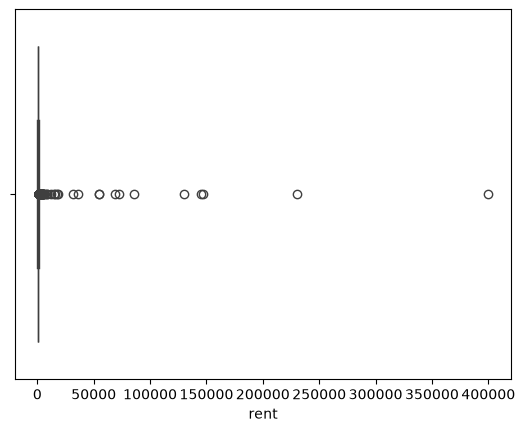

In [18]:
sns.boxplot(x=df['rent'])
plt.show()

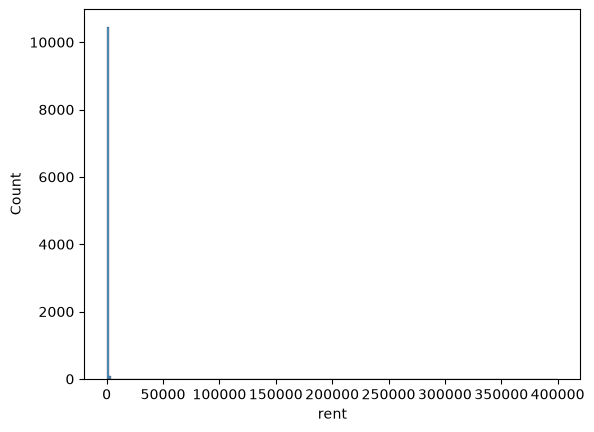

In [19]:
sns.histplot(df['rent'])
plt.show()

In [20]:
df[df['rent'] > 5000]
# these are outliers

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
292,657,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Exclusive Offer | Resort-Style Living | Spacious,"Breeze of Dilmunia, Dilmunia Island",Muharraq Governorate,1,2,"1,012 sqft / 94 sqm",25 Sep 2025,Anjum Jawaid,River West Properties,14.0,72000.0
364,11375,Rent,https://www.propertyfinder.bh/en/plp/rent/whol...,Whole Building,Exclusive,Labour Accommodation/Riffa/Whole Bldg./171 Rooms,"Alhajiyat, Riffa",Southern Governorate,7+,7+,"147,918 sqft / 13,742 sqm",26 May 2025,City Property,City Property,4.0,12000.0
1200,9408,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Five-Star Residence with Iconic Skyline Views,Bahrain Bay,Capital Governorate,3+ Maid,4,"2,874 sqft / 267 sqm",24 Jun 2025,Mahmoud Marzouk,HighBridge,18.0,5250.0
1242,3672,Rent,https://www.propertyfinder.bh/en/plp/rent/whol...,Whole Building,Exclusive,"Entire New Building – Ideal for Staff, Great Spot","Gudaibiya, Manama",Capital Governorate,studio,1,"21,528 sqft / 2,000 sqm",8 Sep 2025,Eva Gavin,Eva Realty,4.0,8400.0
1467,1544,Rent,https://www.propertyfinder.bh/en/plp/rent/whol...,Whole Building,Exclusive,Prestigious Residential Building in Adliya,"Adliya, Manama",Capital Governorate,7++ Maid,7+,"27,523 sqft / 2,557 sqm",20 Sep 2025,Fatima Rahaoui,Kooheji Real Estate & Constructions,11.0,18000.0
2131,11819,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,New Villa in karzakan Size 331 SQM,Karzakkan,Northern Governorate,4+ Maid,5,"4,844 sqft / 450 sqm",24 Feb 2025,Hussain Al Mesbah,Effects Services,1.0,146500.0
2960,13070,Rent,https://www.propertyfinder.bh/en/plp/rent/whol...,Whole Building,Exclusive,Prime location | Corner Street | One cheque,Al Juffair,Capital Governorate,7+,7+,"9,569 sqft / 889 sqm",10 Mar 2025,Saud Nasser,Domestic Designs,6.0,14500.0
3311,7717,Rent,https://www.propertyfinder.bh/en/plp/rent/pent...,Penthouse,Inclusive,LUXURY LIVING WITH CRYSTAL BLUE HORIZON,Bahrain Bay,Capital Governorate,4+ Maid,6,"4,413 sqft / 410 sqm",1 Aug 2025,Farhan Tariq,BHH Real Estate,17.0,6500.0
3810,10706,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Inclusive,Modern | For Rent &amp; Sale | Sea View + Balcony,"Durrat Marina, Durrat Al Bahrain",Southern Governorate,2,3,"1,292 sqft / 120 sqm",29 Apr 2025,Yusuf Alsobaiei,Aqaratcom For Real Estate,14.0,55000.0
4134,7105,Rent,https://www.propertyfinder.bh/en/plp/rent/pent...,Penthouse,Inclusive,PENTHOUSE | LUXURIOUS | MAID ROOM | SEA VIEW,Bahrain Bay,Capital Governorate,4+ Maid,6,"4,413 sqft / 410 sqm",6 Aug 2025,Gulnaz Amangeldinova,Glory Real Estate,15.0,5500.0


In [21]:
df.sort_values('rent', ascending=False).head(15)

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
7195,10705,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Spacious Villa | Patel 5 | 4 Bedrooms,Durrat Al Bahrain,Southern Governorate,4+ Maid,6,"5,866 sqft / 545 sqm",29 Apr 2025,Yusuf Alsobaiei,Aqaratcom For Real Estate,17.0,400000.0
9399,13289,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,UNDER CONSTRUCTION VILLA IN MUHARRAQ,Muharraq,Muharraq Governorate,6,7,"4,036 sqft / 375 sqm",NaN,Hussain Nayem,DELTA REAL ESTATE,NaN,230000.0
2131,11819,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,New Villa in karzakan Size 331 SQM,Karzakkan,Northern Governorate,4+ Maid,5,"4,844 sqft / 450 sqm",24 Feb 2025,Hussain Al Mesbah,Effects Services,1.0,146500.0
7248,6116,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Amazing House for Sale in Hidd,Hidd,Muharraq Governorate,5,7+,"5,813 sqft / 540 sqm",19 Aug 2025,Najeeb Hejres,Green Line Real Estate,4.0,145000.0
4397,11498,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Villa for sale in Sadad,Sadad,Northern Governorate,4,5,"2,939 sqft / 273 sqm",NaN,Ali AlMahafdha,Grnata,NaN,130000.0
9018,11623,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,| CITY CENTER | MODERN | CITY VIEW | HIGH FLOOR |,Seef,Capital Governorate,2+ Maid,2,"1,432 sqft / 133 sqm",6 Mar 2025,Gulnaz Amangeldinova,Glory Real Estate,17.0,86000.0
292,657,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Exclusive Offer | Resort-Style Living | Spacious,"Breeze of Dilmunia, Dilmunia Island",Muharraq Governorate,1,2,"1,012 sqft / 94 sqm",25 Sep 2025,Anjum Jawaid,River West Properties,14.0,72000.0
7277,12923,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,High Floor | Mall View | Beach Access,"Marassi Shores Residences, Diyar Al Muharraq",Muharraq Governorate,1,1,710 sqft / 66 sqm,NaN,Hussain Nayem,DELTA REAL ESTATE,8.0,69000.0
3810,10706,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Inclusive,Modern | For Rent &amp; Sale | Sea View + Balcony,"Durrat Marina, Durrat Al Bahrain",Southern Governorate,2,3,"1,292 sqft / 120 sqm",29 Apr 2025,Yusuf Alsobaiei,Aqaratcom For Real Estate,14.0,55000.0
4602,11601,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,BRAND NEW BUILDING | PRIME LOCATION | 3BHK,Hamad Town,Northern Governorate,3,4,"1,561 sqft / 145 sqm",28 May 2025,Green Line,Green Line Real Estate,5.0,55000.0


In [22]:
print(f'rent > 10000: {(df['rent'] > 10000).sum()}')
print(f'rent > 5000 : {(df['rent'] > 5000).sum()}')
print(f'rent > 2000 : {(df['rent'] > 2000).sum()}')
print(f'rent < 100  : {(df['rent'] < 100).sum()}')

rent > 10000: 17
rent > 5000 : 22
rent > 2000 : 111
rent < 100  : 3


In [23]:
df.sort_values('rent').head(10)
# to see the lowest

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
8581,3156,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,For rent studio for special price in Manama,Manama,Capital Governorate,1,1,323 sqft / 30 sqm,11 Sep 2025,Yes Real Estate,Yes Real Estate,1.0,50.0
5427,3177,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,For Rent small studio for special price in Manama,Manama,Capital Governorate,1,1,323 sqft / 30 sqm,11 Sep 2025,Ali Alkhunaizi,Yes Real Estate,1.0,50.0
4381,11858,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Elegant Semi Furnished 1 Bedroom Apartment,Salmabad,Central Governorate,1,1,269 sqft / 25 sqm,1 Sep 2024,Al-Ahlia Real Estate,Al-Ahlia Real Estate,NaN,90.0
2974,9526,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,2BHK in very low BUDGET in MUHARRAQ,Muharraq,Muharraq Governorate,2,2,915 sqft / 85 sqm,19 Jun 2025,Dhurgham Ali,AYS Real Estate,1.0,100.0
526,569,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Studio for rent including electricity,Hidd,Muharraq Governorate,studio,1,538 sqft / 50 sqm,25 Sep 2025,khaled alghaiathi,Paradise House Real Estate,2.0,100.0
10234,12916,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,For rent nice 1bhk in sitra,Sitra,Central Governorate,1,1,646 sqft / 60 sqm,23 Oct 2024,Yes Real Estate,Yes Real Estate,NaN,100.0
1214,10849,Rent,https://www.propertyfinder.bh/en/plp/rent/bulk...,Bulk Rent Unit,Inclusive,Bulk Rooms for rent in Muharraq,Muharraq,Muharraq Governorate,0,7+,"2,153 sqft / 200 sqm",22 Apr 2025,Azhar Uddin,Capital Estate,1.0,100.0
3065,11264,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Studio for rent in Manama in front of Bab Al B...,"Manama Sea Front, Manama",Capital Governorate,studio,1,807 sqft / 75 sqm,25 Mar 2025,Hussain Hammadi,Hammadi Real Estate Construction And Document ...,1.0,100.0
3209,12393,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,2BHK Flat in Busaiteen| Affordable Price,Busaiteen,Muharraq Governorate,2,1,915 sqft / 85 sqm,5 Jan 2025,Dhurgham Ali,AYS Real Estate,1.0,100.0
1915,9528,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,2BHK for FAMILIES in affordable BUDGET | BUSAI...,Busaiteen,Muharraq Governorate,2,2,"1,076 sqft / 100 sqm",19 Jun 2025,Dhurgham Ali,AYS Real Estate,1.0,100.0


In [24]:
# temporary dataframe without the impossible rents
df_temp = df[df['rent'] <= 5000]

print(f"rows before: {df.shape[0]}")
print(f"rows after : {df_temp.shape[0]}")

rows before: 10578
rows after : 10553


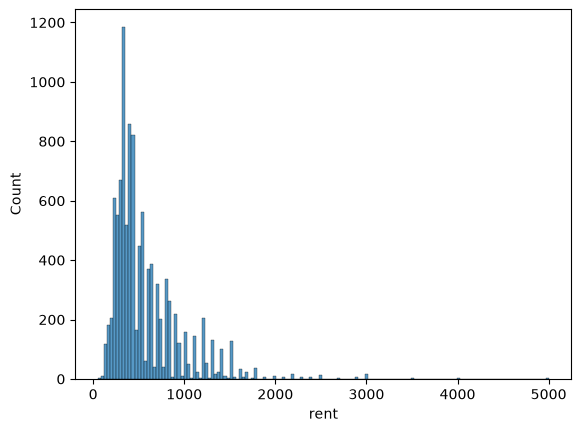

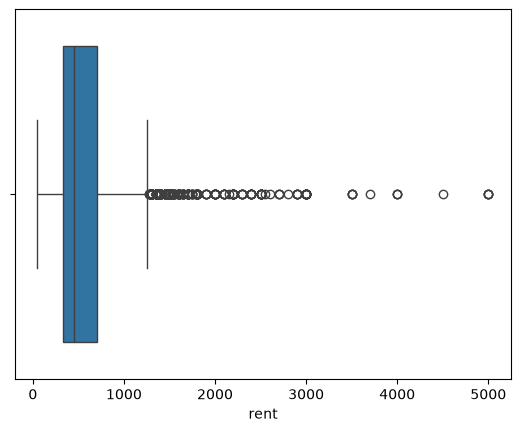

In [25]:
sns.histplot(df_temp['rent'])
plt.show()

sns.boxplot(x=df_temp['rent'])
plt.show()

In [26]:
# check correlation with the target
df.corr(numeric_only=True)[['rent']]

,rent
Property_id,0.019748
Amenities,0.023892
rent,1.000000


In [27]:
# TEMPORARY conversion - only to look at correlation
temp = df.copy()

temp['size_sqm'] = temp['Size'].str.split('/').str[1].str.replace('sqm', '').str.replace(',', '').astype(float)
temp['beds_n'] = temp['Beds'].str.replace('studio', '0').str[0].astype(float)
temp['baths_n'] = pd.to_numeric(temp['Baths'].str[0], errors='coerce')

temp[['Size', 'size_sqm', 'Beds', 'beds_n', 'Baths', 'baths_n']].head()

,Size,size_sqm,Beds,beds_n,Baths,baths_n
0,"2,368 sqft / 220 sqm",220.0,3+ Maid,3.0,4,4.0
1,"3,229 sqft / 300 sqm",300.0,5,5.0,6,6.0
2,484 sqft / 45 sqm,45.0,studio,0.0,1,1.0
3,"1,507 sqft / 140 sqm",140.0,3,3.0,3,3.0
4,"4,844 sqft / 450 sqm",450.0,5+ Maid,5.0,5,5.0


In [28]:
# correlation with rent using ALL the rows
temp[['size_sqm', 'beds_n', 'baths_n', 'Amenities', 'rent']].corr()[['rent']]

,rent
size_sqm,0.085948
beds_n,0.083336
baths_n,0.103176
Amenities,0.023892
rent,1.000000


In [29]:
# the SAME correlation, but after removing the impossible rents
temp_clean = temp[temp['rent'] <= 5000]

temp_clean[['size_sqm', 'beds_n', 'baths_n', 'Amenities', 'rent']].corr()[['rent']]

,rent
size_sqm,0.704415
beds_n,0.639968
baths_n,0.724340
Amenities,0.268085
rent,1.000000


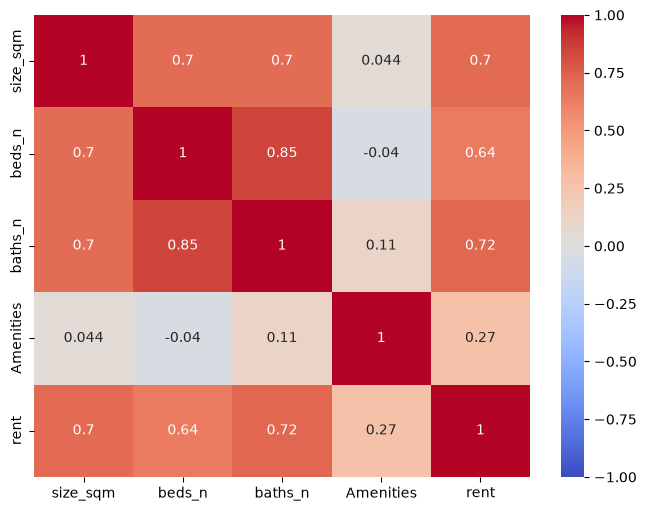

In [30]:
plt.figure(figsize=(8, 6))
sns.heatmap(temp_clean[['size_sqm', 'beds_n', 'baths_n', 'Amenities', 'rent']].corr(),
            annot=True,
            vmin=-1,
            vmax=1,
            cmap='coolwarm')
plt.show()

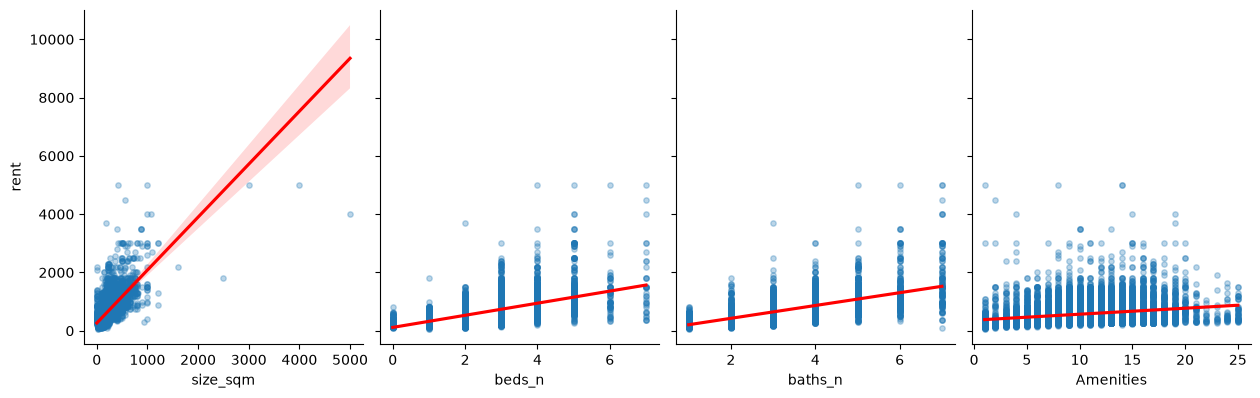

In [31]:
sns.pairplot(temp_clean,
             x_vars=['size_sqm', 'beds_n', 'baths_n', 'Amenities'],
             y_vars='rent',
             height=4,
             aspect=0.8,
             kind='reg',
             plot_kws={'scatter_kws': {'alpha': 0.3, 's': 15},
                       'line_kws': {'color': 'red'}})
plt.show()

In [32]:
# median rent for each governorate, sorted from the most expensive
temp_clean.groupby('Governorate')['rent'].median().sort_values(ascending=False)

Governorate
Northern Governorate    700.0
Southern Governorate    480.0
Capital Governorate     425.0
Muharraq Governorate    400.0
Central Governorate     272.5
Name: rent, dtype: float64

In [33]:
# median rent for each property type
temp_clean.groupby('Property_type')['rent'].median().sort_values(ascending=False)

Property_type
Whole Building                  1500.0
Penthouse                       1000.0
Villa                            950.0
Compound                         850.0
Bungalow                         800.0
Duplex                           704.0
Hotel Apartment                  700.0
Townhouse                        650.0
Apartment                        400.0
Short Term & Hotel Apartment     320.0
Bulk Rent Unit                   100.0
Name: rent, dtype: float64

In [34]:
temp_clean.groupby('Include_w_e')['rent'].median()

Include_w_e
Exclusive    525.0
Inclusive    425.0
Name: rent, dtype: float64

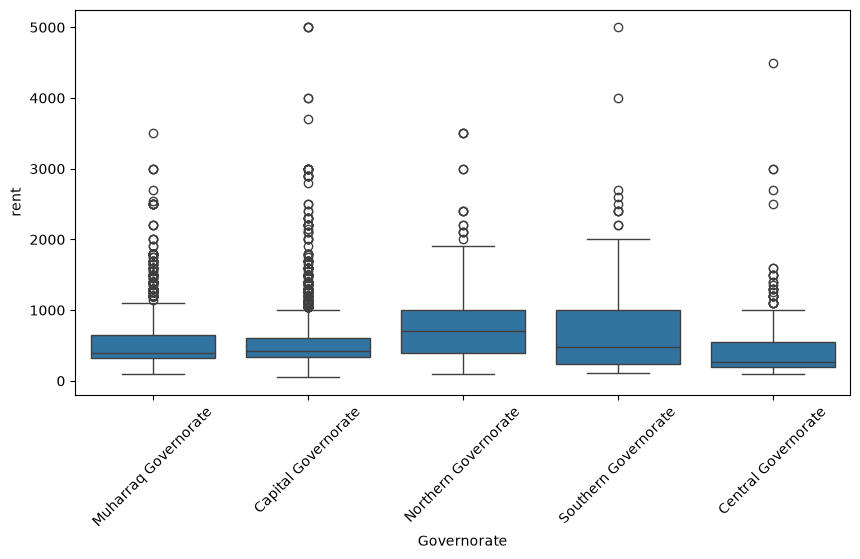

In [35]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=temp_clean, x='Governorate', y='rent')
plt.xticks(rotation=45)
plt.show()

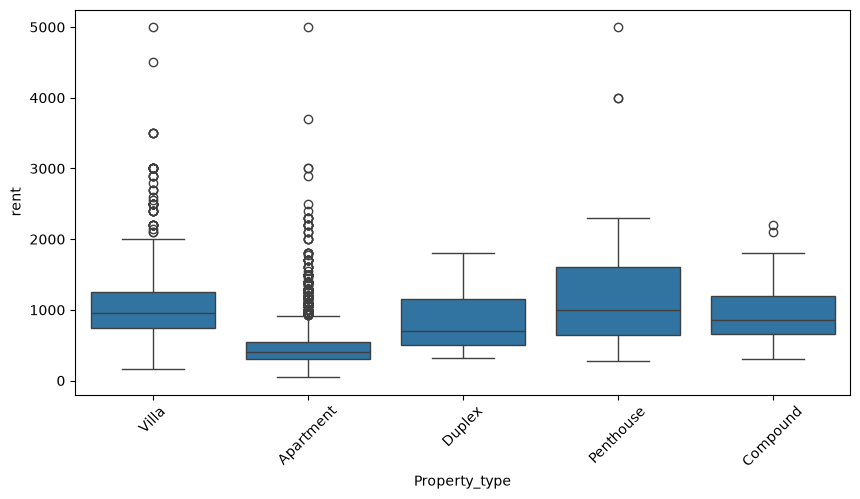

In [36]:
# boxplot of rent by property type, keeping only the main types so the plot stays readable
main_types = ['Apartment', 'Villa', 'Compound', 'Duplex', 'Penthouse']

plt.figure(figsize=(10, 5))
sns.boxplot(data=temp_clean[temp_clean['Property_type'].isin(main_types)], x='Property_type', y='rent')
plt.xticks(rotation=45)
plt.show()

In [37]:
df[df['rent'].isnull()]

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
5194,125,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,NaN,NaN,NaN,2,4,"1,399 sqft / 130 sqm",NaN,NaN,NaN,5.0,NaN
6787,25,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,NaN,NaN,NaN,2,4,"1,399 sqft / 130 sqm",NaN,NaN,NaN,5.0,NaN
7864,9012,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,NaN,NaN,NaN,2,2,"1,184 sqft / 110 sqm",NaN,NaN,NaN,8.0,NaN


In [38]:
# is Amenities missing randomly, or does missing mean something?
print(f"median rent when Amenities is missing: {df[df['Amenities'].isnull()]['rent'].median()}")
print(f"median rent when Amenities is present: {df[df['Amenities'].notnull()]['rent'].median()}")

median rent when Amenities is missing: 380.0
median rent when Amenities is present: 450.0


In [39]:
# Size gives us the SAME information twice (sqft and sqm), let's prove it
temp['size_sqft'] = temp['Size'].str.split('/').str[0].str.replace('sqft', '').str.replace(',', '').astype(float)

temp[['size_sqft', 'size_sqm']].corr()

,size_sqft,size_sqm
size_sqft,1.0,1.0
size_sqm,1.0,1.0


In [40]:
df_clean = df.copy()
test_clean = test.copy()

print('rows at the start:', df_clean.shape[0])

rows at the start: 10578


In [41]:
# 1_drop the rows where the target is missing, a row with no rent teaches the model nothing
df_clean = df_clean.dropna(subset=['rent'])
print('after dropping null rent:', df_clean.shape[0])

after dropping null rent: 10575


In [42]:
# 2_drop duplicated listings
#     the same ad was saved twice under two different Property_id
#     so we judge duplicates by the URL, because one link = one property
print('duplicated listings:', df_clean.duplicated(subset=['URL']).sum())

df_clean = df_clean.drop_duplicates(subset=['URL'])
print('after dropping duplicates:', df_clean.shape[0])

duplicated listings: 240
after dropping duplicates: 10335


In [43]:
# 3_drop the impossible rents (huge rents / sale prices in the wrong column)
print('rows with rent > 5000:', (df_clean['rent'] > 5000).sum())

df_clean = df_clean[df_clean['rent'] <= 5000]
print('after dropping impossible rents:', df_clean.shape[0])

rows with rent > 5000: 21
after dropping impossible rents: 10314


In [44]:
df_clean = df_clean.reset_index(drop=True)

In [45]:
# A function to do all the column cleaning, to run it on both train and test,


def clean_columns(df):
    '''
    Converts the text columns into numbers,
    and drops the columns we no longer need.
    Works for both the train file and the test file.
    '''
    df = df.copy()

    # we keep sqm only, because sqft and sqm correlate 0.9999 (multicollinearity)
    df['size_sqm'] = (df['Size'].str.split('/').str[1].str.replace('sqm', '').str.replace(',', '').astype(float))

    # a size of exactly 1 sqm is not a real property, we turn it into null and let the pipeline fill it later
    df.loc[df['size_sqm'] == 1, 'size_sqm'] = np.nan

    # Beds : '3+ Maid' -> 3 , 'studio' -> 0
    df['beds_n'] = df['Beds'].str.replace('studio', '0').str[0].astype(float)

    # the "+ Maid" part is real information, so we save it as its own column before losing it
    df['has_maid_room'] = df['Beds'].str.contains('Maid').astype(int)

    # a studio is not the same as a 0-bedroom property, so we flag it too
    df['is_studio'] = df['Beds'].str.contains('studio').astype(int)

    # Baths : "7+" -> 7 , "none" -> null
    df['baths_n'] = pd.to_numeric(df['Baths'].str[0], errors='coerce')

    # Availability_date : "9 Apr 2025" -> a real date 
    df['avail_date'] = pd.to_datetime(df['Availability_date'],format='%d %b %Y',errors='coerce')

    # drop the columns we do not need anymore
    # Offer: always "Rent", it never changes, so it teaches nothing
    # Size, Beds, Baths, Availability_date : we replaced them with the numeric versions
    df = df.drop(columns=['Offer', 'Size', 'Beds', 'Baths', 'Availability_date'])

    return df

In [46]:
df_clean = clean_columns(df_clean)
test_clean = clean_columns(test_clean)

print('train df shape:', df_clean.shape)
print('test df shape:', test_clean.shape)

train df shape: (10314, 17)
test df shape: (3527, 16)


In [47]:
df_clean.dtypes

Property_id               int64
URL                         str
Property_type               str
Include_w_e                 str
Title                       str
Area                        str
Governorate                 str
Agent_name                  str
Agency                      str
Amenities               float64
rent                    float64
size_sqm                float64
beds_n                  float64
has_maid                  int64
is_studio                 int64
baths_n                 float64
avail_date       datetime64[us]
dtype: object

In [48]:
df_clean[['size_sqm', 'beds_n', 'baths_n', 'has_maid', 'is_studio', 'Amenities', 'rent']].describe()

,size_sqm,beds_n,baths_n,has_maid,is_studio,Amenities,rent
count,10203.000000,10314.000000,10313.000000,10314.000000,10314.000000,10014.000000,10314.000000
mean,170.589238,2.198274,2.658683,0.209909,0.057495,10.304773,570.592399
std,150.935291,1.200679,1.285646,0.407263,0.232797,5.091589,388.285575
min,2.000000,0.000000,1.000000,0.000000,0.000000,1.000000,50.000000
25%,90.000000,1.000000,2.000000,0.000000,0.000000,6.000000,330.000000
50%,125.000000,2.000000,2.000000,0.000000,0.000000,11.000000,450.000000
75%,180.000000,3.000000,3.000000,0.000000,0.000000,14.000000,700.000000
max,5000.000000,7.000000,7.000000,1.000000,1.000000,25.000000,5000.000000


In [49]:
print(df_clean.isnull().sum())
print(test_clean.isnull().sum())

Property_id        0
URL                0
Property_type      0
Include_w_e        0
Title              0
Area               0
Governorate        0
Agent_name         0
Agency             0
Amenities        300
rent               0
size_sqm         111
beds_n             0
has_maid           0
is_studio          0
baths_n            1
avail_date       511
dtype: int64
Property_id        0
URL                0
Property_type      0
Include_w_e        0
Title              0
Area               0
Governorate        0
Agent_name         0
Agency             0
Amenities         86
size_sqm          34
beds_n             0
has_maid           0
is_studio          0
baths_n            2
avail_date       168
dtype: int64


In [50]:
print('rent skew before cleaning:', df['rent'].skew())
print('rent skew after cleaning :', df_clean['rent'].skew())

rent skew before cleaning: 53.889106111650975
rent skew after cleaning : 2.800236468092748


In [51]:
df_clean[['size_sqm', 'beds_n', 'baths_n', 'has_maid', 'is_studio', 'Amenities', 'rent']].corr()[['rent']]

,rent
size_sqm,0.713722
beds_n,0.641859
baths_n,0.726056
has_maid,0.562693
is_studio,-0.189444
Amenities,0.267738
rent,1.000000


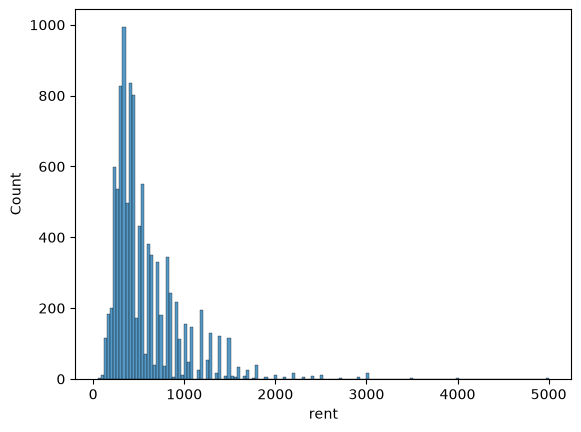

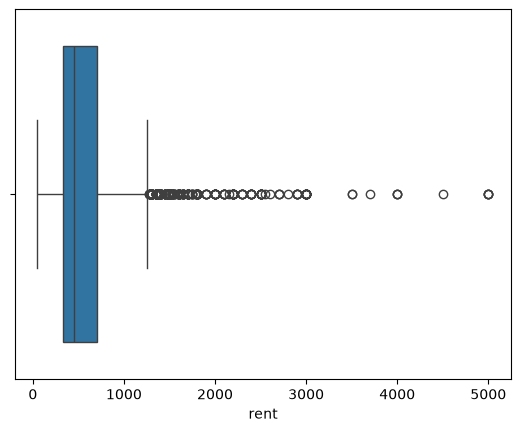

In [52]:
sns.histplot(df_clean['rent'])
plt.show()

sns.boxplot(x=df_clean['rent'])
plt.show()

In [53]:
df_feat = df_clean.copy()
test_feat = test_clean.copy()

In [54]:
# total number of rooms = bedrooms + bathrooms
df_feat['total_rooms'] = df_feat['beds_n'] + df_feat['baths_n']

# how much space per room
df_feat['sqm_per_room'] = df_feat['size_sqm'] / df_feat['total_rooms']

df_feat[['beds_n', 'baths_n', 'total_rooms', 'size_sqm', 'sqm_per_room']].head()

,beds_n,baths_n,total_rooms,size_sqm,sqm_per_room
0,3.0,4.0,7.0,220.0,31.428571
1,5.0,6.0,11.0,300.0,27.272727
2,0.0,1.0,1.0,45.0,45.000000
3,3.0,3.0,6.0,140.0,23.333333
4,5.0,5.0,10.0,450.0,45.000000


In [55]:
# check if the new columns are actually useful
df_feat[['total_rooms', 'sqm_per_room', 'rent']].corr()[['rent']]

,rent
total_rooms,0.712739
sqm_per_room,0.324652
rent,1.000000


In [56]:
df_feat['Title'].head(10)

0               BTRAND NEW LUXURY VILLA FOR RENT AMWAJ
1              First Resident | Quiet Area | Luxurious
2         Studio Apartment for rent located in Juffair
3       Apartment for Rent in Jidhafs – Prime Location
4          Navy Approved| 5 BR | Private Pool |Gardens
5           AMWAJ ISLAND | LUXURIOUS | PRIME LOCATIONS
6    Fully Furnished Beautiful Villa with Private Pool
7    Spacious 4BR Villa with Private Pool in Busaiteen
8    Luxury apartment 2BHK furnished including for ...
9                   Sea View | Luxury Living | Terrace
Name: Title, dtype: str

In [57]:
# a test on one keyword before we do them all
title_lower = df_feat['Title'].str.lower()

df_feat['has_pool'] = title_lower.str.contains('pool').astype(int)

print(df_feat['has_pool'].value_counts())
print('median rent when pool is mentioned    :', df_feat[df_feat['has_pool'] == 1]['rent'].median())
print('median rent when pool is NOT mentioned:', df_feat[df_feat['has_pool'] == 0]['rent'].median())

has_pool
0    8950
1    1364
Name: count, dtype: int64
median rent when pool is mentioned    : 700.0
median rent when pool is NOT mentioned: 425.0


In [58]:
# now for a list of keywords using a for loop
keywords = ['furnish', 'sea view', 'luxur', 'pool', 'gym', 'private','garden', 'compound', 'maid', 'beach', 'balcony', 'view', 'new', 'modern']

title_lower = df_feat['Title'].str.lower()

for word in keywords:
    new_col = 'has_' + word.replace(' ', '_')
    df_feat[new_col] = title_lower.str.contains(word).astype(int)

keyword_cols = ['has_' + word.replace(' ', '_') for word in keywords]

df_feat[keyword_cols].head()

,has_furnish,has_sea_view,has_luxur,has_pool,has_gym,has_private,has_garden,has_compound,has_maid,has_beach,has_balcony,has_view,has_new,has_modern
0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,1,1,0,0,0,0,0,0,0


In [59]:
# how many titles contain each keyword?
df_feat[keyword_cols].sum().sort_values(ascending=False)

has_view        2115
has_furnish     1938
has_balcony     1859
has_luxur       1620
has_pool        1364
has_sea_view    1358
has_modern      1291
has_new         1119
has_private      683
has_garden       649
has_gym          618
has_maid         579
has_beach        431
has_compound     350
dtype: int64

In [60]:
# which keywords actually relate to price?
df_feat[keyword_cols + ['rent']].corr()[['rent']].sort_values('rent', ascending=False)

,rent
rent,1.000000
has_private,0.352588
has_garden,0.276802
has_pool,0.248603
has_compound,0.147588
has_maid,0.121955
has_beach,0.105176
has_luxur,0.089803
has_view,0.071430
has_sea_view,0.065842


In [61]:
df_feat['avail_month'] = df_feat['avail_date'].dt.month

df_feat[['avail_month', 'rent']].corr()[['rent']]

,rent
avail_month,0.036932
rent,1.000000


In [62]:
area_counts = df_feat['Area'].value_counts()
area_counts

Area
Al Juffair                                              1879
Seef                                                     989
Saar                                                     678
Janabiya                                                 518
Hidd                                                     486
                                                        ... 
Al Thurya villa Diyar Al Muharraq, Diyar Al Muharraq       1
Dareena, Dilmunia Island                                   1
Maameer                                                    1
Wahat Al Muharraq                                          1
Adhari, Manama                                             1
Name: count, Length: 126, dtype: int64

In [63]:
# find the areas that appear less than 30 times
rare_areas = area_counts[area_counts < 30].index.to_list()

print('number of rare areas:', len(rare_areas))
print(rare_areas[:10])

number of rare areas: 79
['Maqabah', 'Jannusan', 'Hoora', 'Water Garden City, Manama', 'Manama', 'Riffa Al Sharqi, Riffa', 'Alhajiyat, Riffa', "A'Ali", 'Riffa', 'Gudaibiya, Manama']


In [64]:
# replace all those rare areas with the single label 'Other'
df_feat['Area_grouped'] = df_feat['Area'].replace(rare_areas, 'Other')

print('areas before grouping:', df_feat['Area'].nunique())
print('areas after grouping :', df_feat['Area_grouped'].nunique())
print(df_feat['Area_grouped'].value_counts().head(10))

areas before grouping: 126
areas after grouping : 48
Area_grouped
Al Juffair                     1879
Seef                            989
Other                           818
Saar                            678
Janabiya                        518
Hidd                            486
Amwaj Avenue, Amwaj Islands     422
Busaiteen                       361
Mahooz, Manama                  349
Adliya, Manama                  303
Name: count, dtype: int64


In [65]:
# do the same for the agencies, with a bigger threshold since there are more of them
agency_counts = df_feat['Agency'].value_counts()
rare_agencies = agency_counts[agency_counts < 50].index.to_list()

df_feat['Agency_grouped'] = df_feat['Agency'].replace(rare_agencies, 'Other')

print('agencies before grouping:', df_feat['Agency'].nunique())
print('agencies after grouping :', df_feat['Agency_grouped'].nunique())

agencies before grouping: 204
agencies after grouping : 65


In [66]:
# A function that creates all our new features, on BOTH train and test so they stay identical


def add_features(df):
    '''
    Creates the ratio features, the Title keyword flags, and the month feature.
    '''
    df = df.copy()

    # combining the numbers
    df['total_rooms'] = df['beds_n'] + df['baths_n']
    df['sqm_per_room'] = df['size_sqm'] / df['total_rooms']

    # keyword flags from the Title
    title_lower = df['Title'].str.lower()
    for word in keywords:
        new_col = 'has_' + word.replace(' ', '_')
        df[new_col] = title_lower.str.contains(word).astype(int)

    # date
    df['avail_month'] = df['avail_date'].dt.month

    return df

In [67]:
df_feat = add_features(df_clean)
test_feat = add_features(test_clean)

print('train shape:', df_feat.shape)
print('test  shape:', test_feat.shape)

train shape: (10314, 33)
test  shape: (3527, 32)


In [68]:
# now the grouped categories

area_counts = df_feat['Area'].value_counts()
rare_areas = area_counts[area_counts < 30].index.to_list()

agency_counts = df_feat['Agency'].value_counts()
rare_agencies = agency_counts[agency_counts < 50].index.to_list()

# apply the SAME lists to both files
df_feat['Area_grouped'] = df_feat['Area'].replace(rare_areas, 'Other')
test_feat['Area_grouped'] = test_feat['Area'].replace(rare_areas, 'Other')

df_feat['Agency_grouped'] = df_feat['Agency'].replace(rare_agencies, 'Other')
test_feat['Agency_grouped'] = test_feat['Agency'].replace(rare_agencies, 'Other')

print('train areas:', df_feat['Area_grouped'].nunique())
print('test  areas:', test_feat['Area_grouped'].nunique())

train areas: 48
test  areas: 49


In [69]:
# check for any category that exists in test but not in train
print('areas in test but not in train   :', set(test_feat['Area_grouped'].unique()) - set(df_feat['Area_grouped'].unique()))
print('agencies in test but not in train:', set(test_feat['Agency_grouped'].unique()) - set(df_feat['Agency_grouped'].unique()))

areas in test but not in train   : {'Dumistan'}
agencies in test but not in train: {'Bin Ghareeb Trading Company W.L.L'}


In [70]:
# check the new columns have no strange values
df_feat[['total_rooms', 'sqm_per_room', 'avail_month']].describe()

,total_rooms,sqm_per_room,avail_month
count,10313.000000,10202.000000,9803.000000
mean,4.857171,34.292193,7.516271
std,2.390841,14.707475,2.125288
min,1.000000,0.200000,1.000000
25%,3.000000,26.000000,7.000000
50%,4.000000,30.000000,8.000000
75%,6.000000,38.888889,9.000000
max,14.000000,470.000000,12.000000


In [71]:
# full correlation view of everything numeric we now have
df_feat.corr(numeric_only=True)[['rent']].sort_values('rent', ascending=False)

,rent
rent,1.000000
baths_n,0.726056
size_sqm,0.713722
total_rooms,0.712739
beds_n,0.641859
has_private,0.352588
sqm_per_room,0.324652
has_garden,0.276802
Amenities,0.267738
has_pool,0.248603
